In [2]:
import os
import h5py
import pywt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from typing import List, Tuple
from scipy.stats import entropy
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from utils import process_file, label_lab, experiment_based_classification
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler

## Load data

In [3]:
## Load stimuli
file = "../data/1D_brownian_stimuli_responses/MR-0644_brownian_stimuli.h5"
ts = []
with h5py.File(file, "r") as f:
    for key in f.keys():
        ts.append(f[key]["data"][:])

# ## Load responses
path = '../data/1D_brownian_stimuli_responses/'

# List all files in the directory
files = os.listdir(path)

# Filter only files (exclude directories)
file_names = [f for f in files if os.path.isfile(os.path.join(path, f))]
file_names = [f for f in file_names if "brownian.h5" in f]
print("Files in the directory:", file_names)

def process_file(file_path):
    with h5py.File(path+file_path, 'r') as File:
        events_means = [[] for _ in range(6)]
        for electrode in list(File.keys()):
            events = list(File[electrode].keys())
            for event in events:
                data = File[electrode][f'{event}']['data'][:]
                events_means[int(event[6:])-1].append(data)
        final_means = [np.mean(event, axis=0) for event in events_means]
    return final_means

df = pd.DataFrame({"H":[i for i in range(6)]})
for file in file_names:
    means = process_file(file)
    df[file[:-12]] = means
df = df.drop(columns=["H"])
df = df.T

Files in the directory: ['MR-0644_brownian.h5', 'MR-0645_brownian.h5', 'MR-0648_brownian.h5', 'MR-0649_brownian.h5', 'MR-0654-t1_brownian.h5', 'MR-0654-t2_brownian.h5', 'MR-0655_brownian.h5', 'MR-0656_brownian.h5', 'MR-0657-t2_brownian.h5', 'MR-0658_brownian.h5', 'MR-0659-t1_brownian.h5', 'MR-0659-t2_brownian.h5', 'MR-0661_brownian.h5', 'MR-0662_brownian.h5', 'MR-0663_brownian.h5', 'MR-0665_brownian.h5', 'MR-0667_brownian.h5', 'MR-0668_brownian.h5', 'MR-0669_brownian.h5', 'MR-0674_brownian.h5', 'MR-0676_brownian.h5', 'MR-0677_brownian.h5', 'MR-0678_brownian.h5', 'MR-0679_brownian.h5', 'MR-0680_brownian.h5', 'MR-0681_brownian.h5', 'MR-0682_brownian.h5']


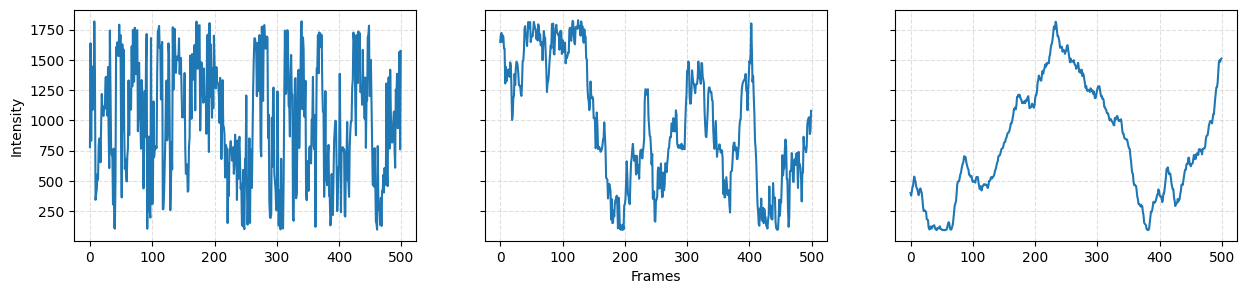

In [3]:
fig, axs = plt.subplots(1,3,sharey=True,figsize=(15,3))
n1 = 500
n2 = 600
n3 = 800
axs[0].plot(ts[0][n1:n1+500])
axs[1].plot(ts[1][n2:n2+500])
axs[2].plot(ts[2][n3:n3+500])
axs[0].set_ylabel("Intensity")
axs[1].set_xlabel("Frames")
axs[0].grid(True,alpha=0.4,linestyle="--")
axs[1].grid(True,alpha=0.4,linestyle="--")
axs[2].grid(True,alpha=0.4,linestyle="--")
plt.show()

## Wavelet-based analysis

In [4]:
groups = {
    "5xFAD_3mF": ['MR-0644', 'MR-0645', 'MR-0648', 'MR-0649'],
    "5xFAD_3mM": ['MR-0661','MR-0663','MR-0667'],
    "5xFAD_6mF": ['MR-0659-t1', 'MR-0659-t2', 'MR-0676'],
    "5xFAD_6mM": ['MR-0657-t2', 'MR-0674', 'MR-0656'],
    "WT_3mF": ['MR-0677', 'MR-0678'],
    "WT_3mM": ['MR-0662', 'MR-0665', 'MR-0668', 'MR-0669'],
    "WT_6mF": ['MR-0679', 'MR-0680'],
    "WT_6mM": ['MR-0655', 'MR-0658', 'MR-0654-t1', 'MR-0654-t2', 'MR-0687-t1']
}

colors = {}
for key in groups.keys():
    for value in groups[key]:
        if "5xFAD_3m" in key:
            colors[value] = "r"
        elif "5xFAD_6m" in key:
            colors[value] = "b"
        elif "WT_3m" in key:
            colors[value] = "g"
        elif "WT_6m" in key:
            colors[value] = "m"
        else:
            colors[value] = "k"

for value in df.index:
    if value != "H":
        if value not in colors.keys():
            colors[value] = "k"

def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'
    
def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

wavelet_props = df.copy()
kl_stats = df.copy()

def label_lab(a):
    for key in groups.keys():
        if a in groups[key]:
            return key
        

# Group by color (excluding black)
color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']#list(color_groups.keys())[:4]
labels_sujetos = []
for ex in range(6):
    #fig, ax = plt.subplots(1, figsize=(8, 5))
    
    stimuli_profile = pywt.wavedec(ts[ex], wavelet='db2')
    stimuli_approx = stimuli_profile[0]
    stimuli_total_energy = np.sum(np.square(stimuli_approx))
    stimuli_details = [np.sum(np.square(stimuli_approx))]  # start with approximation energy
    for level_dict in stimuli_profile[1:]:
        level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
        stimuli_total_energy += level_energy
        stimuli_details.append(level_energy)

    stimuli_proportions = [e / stimuli_total_energy for e in stimuli_details]



    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.abs(df.at[df.index[indice], ex])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]  # start with approximation energy
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            wavelet_props.at[df.index[indice], ex] = proportions
            kl_stats.at[df.index[indice], ex] = entropy(stimuli_proportions,proportions)
            if ex == 1:
                l = label_lab(df.index[indice])
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')

entropy_stats = wavelet_props.copy()
for column in entropy_stats.columns:
    if column != "type":
        entropy_stats[column] =  wavelet_props[column].apply(entropy)

wavelet_props['type'] = labels_sujetos
entropy_stats['type'] = labels_sujetos
kl_stats['type'] = labels_sujetos

wavelet_props = wavelet_props[wavelet_props['type'] != "no class"]
entropy_stats = entropy_stats[entropy_stats['type'] != "no class"]
kl_stats = kl_stats[kl_stats['type'] != "no class"]

for column in entropy_stats.columns:
    if column != "type":
        wavelet_props[column] =  wavelet_props[column].apply(lambda x: x[3])

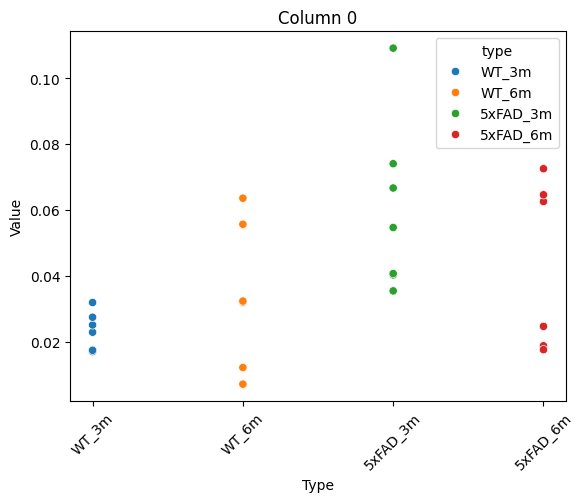

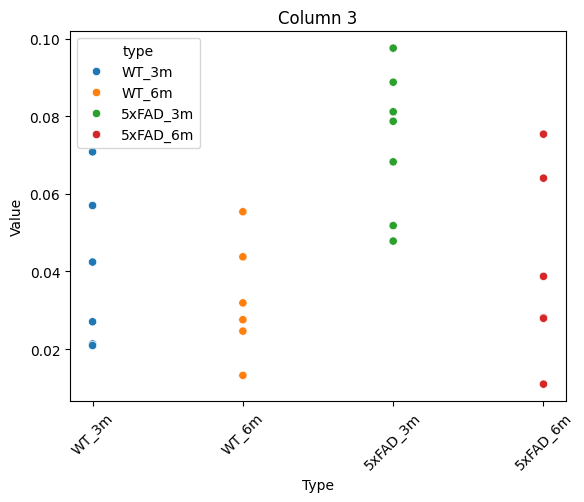

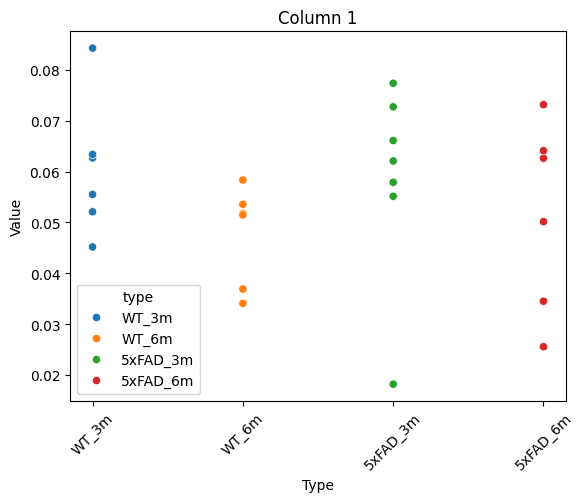

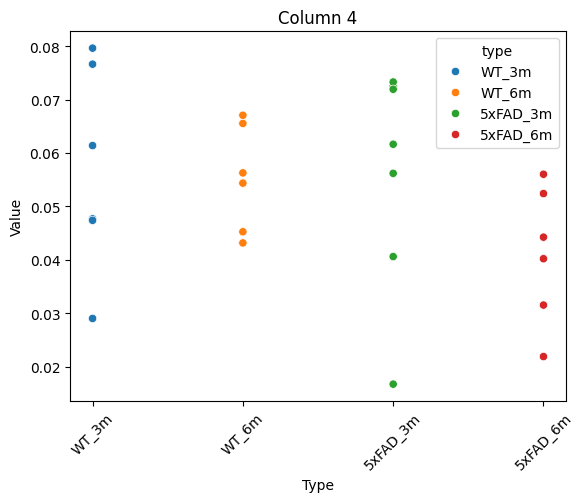

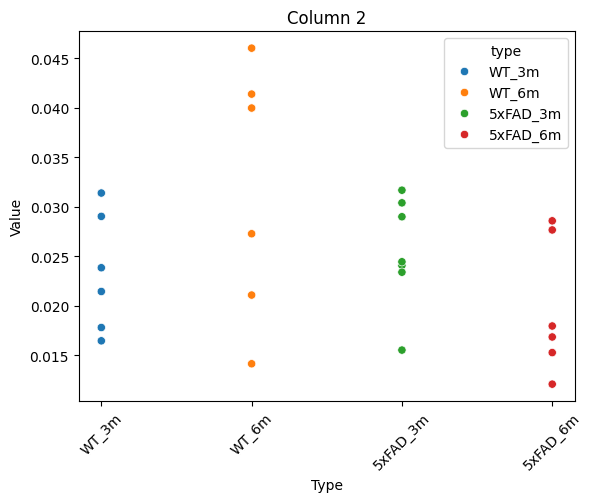

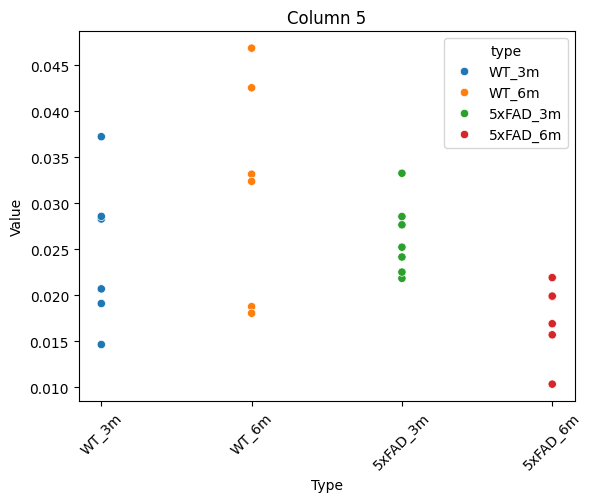

In [5]:
cols = [0,3,1,4,2,5]

for col in cols:
    plt.figure()
    
    sns.scatterplot(
        data=wavelet_props,
        x='type',     # categories on x-axis
        y=col,
        hue='type'
    )
    
    plt.title(f'Column {col}')
    plt.xlabel('Type')
    plt.ylabel('Value')
    plt.xticks(rotation=45)
    
    plt.show()

In [21]:
experiment_based_classification(wavelet_props,age)
print("== entropy ==")
experiment_based_classification(entropy_stats,age)
print("== kl div ==")
experiment_based_classification(kl_stats,age)

LOOCV Accuracy 0: 8.00%
LOOCV Accuracy 1: 52.00%
LOOCV Accuracy 2: 48.00%
LOOCV Accuracy 3: 60.00%
LOOCV Accuracy 4: 48.00%
LOOCV Accuracy 5: 36.00%
== entropy ==
LOOCV Accuracy 0: 36.00%
LOOCV Accuracy 1: 68.00%
LOOCV Accuracy 2: 76.00%
LOOCV Accuracy 3: 56.00%
LOOCV Accuracy 4: 52.00%
LOOCV Accuracy 5: 40.00%
== kl div ==
LOOCV Accuracy 0: 16.00%
LOOCV Accuracy 1: 40.00%
LOOCV Accuracy 2: 64.00%
LOOCV Accuracy 3: 76.00%
LOOCV Accuracy 4: 52.00%


c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LOOCV Accuracy 5: 68.00%


{'0': 0.16, '1': 0.4, '2': 0.64, '3': 0.76, '4': 0.52, '5': 0.68}

In [22]:
experiment_based_classification(wavelet_props,condition)
print("== entropy ==")
experiment_based_classification(entropy_stats,condition)
print("== kl div ==")
experiment_based_classification(kl_stats,condition)

LOOCV Accuracy 0: 68.00%
LOOCV Accuracy 1: 52.00%
LOOCV Accuracy 2: 32.00%


KeyboardInterrupt: 

## coactiv

In [5]:
coactiv_stats = df.copy()
        
# Group by color (excluding black)
color_groups = {}
for i in range(0,len(df.index)):
    color = colors[df.index[i]]
    if color != "black":
        color_groups.setdefault(color, []).append(i)

selected_colors = ['g','m', 'r', 'b','k']#list(color_groups.keys())[:4]
labels_sujetos = []
for ex in range(6):
    #fig, ax = plt.subplots(1, figsize=(8, 5))
    
    i=0
    for color in selected_colors:
        indices = color_groups[color]
        all_props = []

        for indice in indices:
            corr = np.multiply(ts[ex],np.abs(df.at[df.index[indice], ex])[:7500])
            coeffs = pywt.wavedec(corr, wavelet='db2')
            approx = coeffs[0]

            total_energy = np.sum(np.square(approx))
            details = [np.sum(np.square(approx))]  # start with approximation energy
            for level_dict in coeffs[1:]:
                level_energy = np.sum([np.sum(np.square(arr)) for arr in level_dict])
                total_energy += level_energy
                details.append(level_energy)

            proportions = [e / total_energy for e in details]
            coactiv_stats.at[df.index[indice], ex] = proportions
            if ex == 1:
                l = label_lab(df.index[indice])
                if l!= None:
                    labels_sujetos.append(l[:-1])
                else:
                    labels_sujetos.append('no class')


coactiv_stats['type'] = labels_sujetos
coactiv_stats = coactiv_stats[coactiv_stats["type"]!="no class"]


for column in entropy_stats.columns:
    if column in [0,1,3,4]:
        coactiv_stats[column] =  coactiv_stats[column].apply(lambda x: x[3])
    elif column in [2,5]:
        coactiv_stats[column] =  coactiv_stats[column].apply(lambda x: x[3])

In [ ]:
experiment_based_classification(coactiv_stats,age)
print("== cond ==")
experiment_based_classification(coactiv_stats,condition)


LOOCV Accuracy 0: 28.00%
LOOCV Accuracy 1: 48.00%
LOOCV Accuracy 2: 72.00%
LOOCV Accuracy 3: 36.00%
LOOCV Accuracy 4: 44.00%
LOOCV Accuracy 5: 64.00%
== cond ==
LOOCV Accuracy 0: 68.00%
LOOCV Accuracy 1: 52.00%
LOOCV Accuracy 2: 52.00%
LOOCV Accuracy 3: 68.00%
LOOCV Accuracy 4: 48.00%
LOOCV Accuracy 5: 60.00%


{'0': 0.68, '1': 0.52, '2': 0.52, '3': 0.68, '4': 0.48, '5': 0.6}

## Hurst parameter estimator

In [8]:
from scipy.stats import gaussian_kde, iqr

def kde_entropy(x, base=np.e, use_self=True, bw='silverman', n_mc=5000):
    x = np.asarray(x, float).ravel()
    if isinstance(bw, (int, float)):
        s = np.std(x, ddof=1)
        bw = float(bw) / s                      
    kde = gaussian_kde(x, bw_method=bw)        
    if use_self:                              
        y = kde.resample(n_mc)
        logf = np.log(kde.evaluate(y))
    else:
        logf = np.log(kde.evaluate(x))
    return -np.mean(logf) / np.log(base)


In [9]:
alpha = -0.23791952079438267
beta = 0.27023111858695703
# t = np.linspace(0,200,200)
# H = []
# simulations = []
# entropies = []
# estimates = []
# for h in range(49,0,-1):
#     H.append(h/50)

#     entropy = 0
#     for iter in range(12):
#         sim = fbm(t,h/50)
#         entropy += kde_entropy(sim, use_self=True, bw='silverman')

#     entropy = entropy / 12

#     entropies.append(entropy)
#     estimates.append(alpha+beta*entropy)

# plt.scatter(H,entropies)
# plt.ylabel("entropy")
# plt.xlabel("H")
# plt.show()
# plt.scatter(H,estimates)
# plt.ylabel("$\hat{H}$")
# plt.xlabel("H")
# plt.show()


In [10]:
def rescale_fbm_like(x):
    """
    Rescale a single path so it matches the usual fBm normalization:
    - start at 0
    - increments have unit variance
    Returns the rescaled path y.
    """
    x = np.asarray(x, float).ravel()

    # 1) anchor at zero
    x0 = x - x[0]

    # 2) de-drift increments (just in case) and set std to 1
    dx = np.diff(x0)
    dx = dx - dx.mean()            # mean≈0 for fBm; remove tiny sample drift
    s  = dx.std(ddof=1)
    if s == 0:
        raise ValueError("Zero variance in increments; cannot rescale.")
    # reconstruct path with unit-std increments
    y = np.r_[0.0, np.cumsum(dx / s)]
    return y

def estimate_H_from_series(x, win=100, step=200, alpha=alpha, beta=beta):
    x = np.asarray(x, float).ravel()
    if len(x) < win:
        return np.nan
    e_sum = 0.0
    nwin  = 0
    for j in range(0,5000, step):   # your [0,4000) loop
        seg = x[j:j+win]
        seg = rescale_fbm_like(seg)
        e_sum += kde_entropy(seg, use_self=True, bw='silverman')
        nwin += 1
    if nwin == 0:
        return np.nan
    e_avg = e_sum / nwin
    return alpha + beta * e_avg

In [11]:
series_cols = [c for c in df.columns if c != 'H']

df_out = df.copy()
for c in series_cols:
    df_out[c] = df_out[c].apply(estimate_H_from_series)
    df_out[c] = df_out[c].astype(float)


In [12]:
order = [0, 3, 1, 4, 2, 5]
df_out = df_out[order + [c for c in df.columns if c not in order]]

In [13]:
df_out["type"] = labels_sujetos
df_out = df_out[df_out['type']!='no class']
df_out

,0,3,1,4,2,5,type
MR-0644,0.671626,0.675694,0.666694,0.657054,0.650130,0.646684,WT_3m
MR-0645,0.659469,0.667774,0.641005,0.643180,0.645684,0.648978,WT_3m
MR-0648,0.547218,0.545413,0.551643,0.559197,0.539793,0.537752,WT_3m
MR-0649,0.548438,0.543806,0.569750,0.543237,0.527277,0.540151,WT_3m
MR-0654-t1,0.643857,0.625866,0.645687,0.628751,0.626701,0.611514,WT_3m
MR-0654-t2,0.567659,0.616978,0.587402,0.601228,0.605982,0.603896,WT_3m
MR-0655,0.591405,0.594215,0.593485,0.630368,0.560198,0.553767,WT_6m
MR-0656,0.649567,0.626167,0.640543,0.625402,0.634379,0.616648,WT_6m
MR-0657-t2,0.614200,0.601738,0.649351,0.644506,0.608221,0.615755,WT_6m
MR-0658,0.572131,0.556012,0.571907,0.574737,0.565889,0.568347,WT_6m


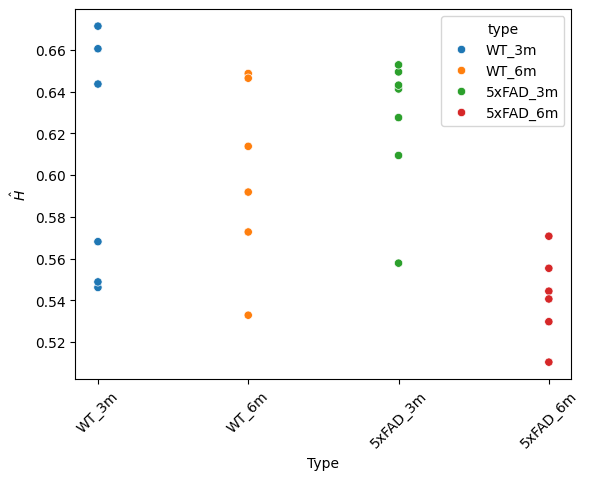

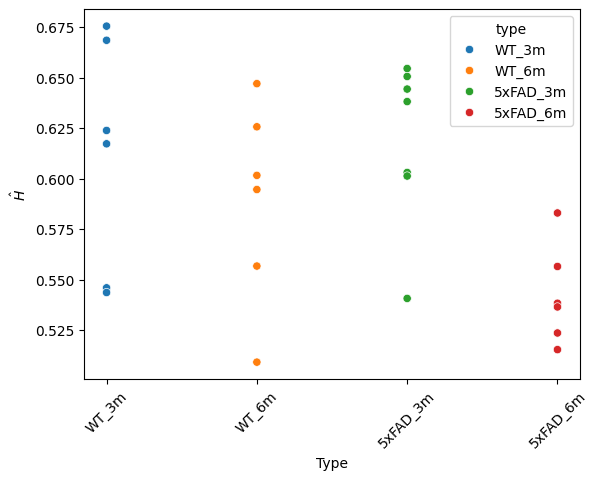

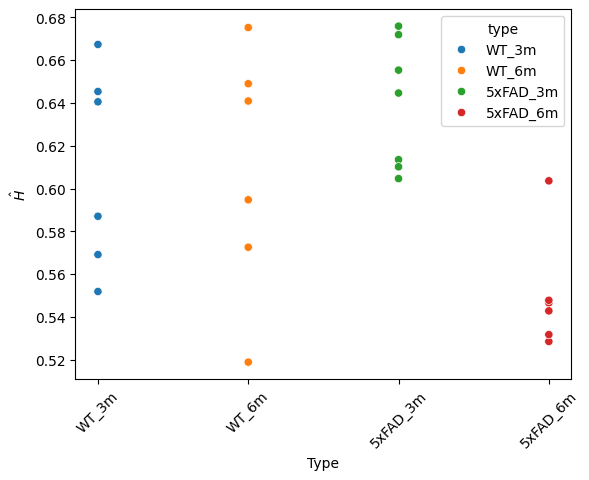

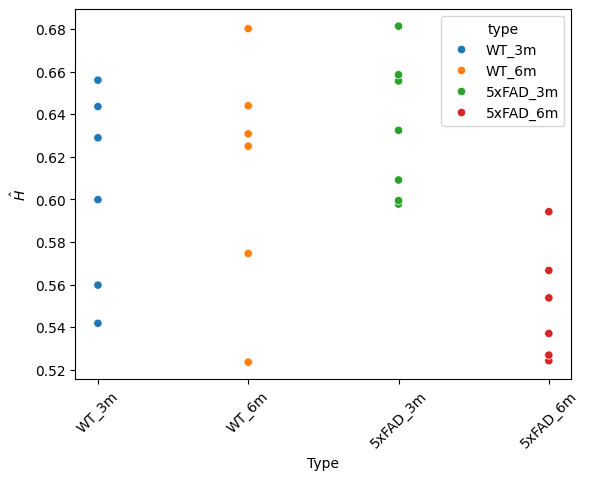

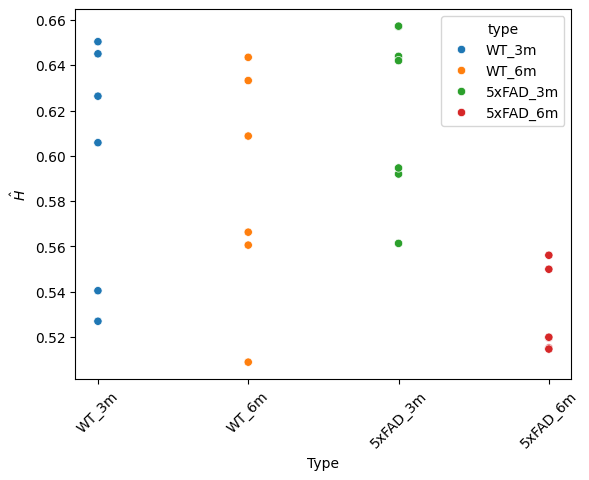

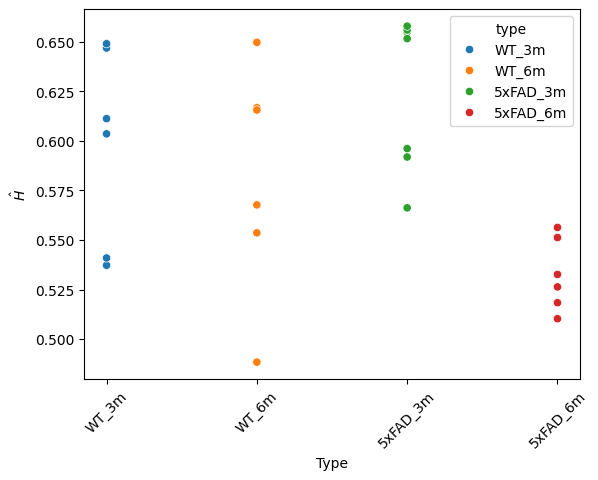

In [31]:
cols = [0,3,1,4,2,5]

for col in cols:
    plt.figure()
    
    sns.scatterplot(
        data=df_out,
        x='type',     # categories on x-axis
        y=col,
        hue='type'
    )
    
    plt.xlabel('Type')
    plt.ylabel('$\hat{H}$')
    plt.xticks(rotation=45)
    
    plt.show()

In [ ]:
experiment_based_classification(df_out,age)

c:\Users\gusco\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\ma\core.py:2892: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


LOOCV Accuracy 0: 52.00%
LOOCV Accuracy 1: 72.00%
LOOCV Accuracy 2: 76.00%
LOOCV Accuracy 3: 68.00%
LOOCV Accuracy 4: 60.00%
LOOCV Accuracy 5: 76.00%


{'0': 0.52, '1': 0.72, '2': 0.76, '3': 0.68, '4': 0.6, '5': 0.76}

In [ ]:
experiment_based_classification(df_out,condition)

LOOCV Accuracy 0: 20.00%
LOOCV Accuracy 1: 68.00%
LOOCV Accuracy 2: 28.00%
LOOCV Accuracy 3: 40.00%
LOOCV Accuracy 4: 28.00%
LOOCV Accuracy 5: 36.00%


{'0': 0.2, '1': 0.68, '2': 0.28, '3': 0.4, '4': 0.28, '5': 0.36}

## Final Results

| Exp | Wavelet Age | Entropy Age | KL Div Age | Co-Act Age | Hurst Age | Wavelet Cond | Entropy Cond | KL Div Cond | Co-Act Cond | Hurst Cond |
|-----|-------------|-------------|------------|------------|-----------|--------------|--------------|-------------|-------------|------------|
| 0   | 8.00%       | 36.00%      | 16.00%     | 28.00%     | 52.00%    | <span style="background-color:#90EE90">68.00%</span> | 52.00%      | 60.00%     | <span style="background-color:#90EE90">68.00%</span> | 20.00%    |
| 1   | 52.00%      | <span style="background-color:#90EE90">68.00%</span> | 40.00%     | 48.00%     | <span style="background-color:#90EE90">72.00%</span> | 52.00%       | 20.00%       | 32.00%     | 52.00%     | <span style="background-color:#90EE90">68.00%</span> |
| 2   | 48.00%      | <span style="background-color:#00FF00">76.00%</span> | 64.00%     | <span style="background-color:#90EE90">72.00%</span> | <span style="background-color:#00FF00">76.00%</span> | 32.00%       | 60.00%      | 48.00%     | 52.00%     | 28.00%    |
| 3   | 60.00%      | 56.00%      | <span style="background-color:#00FF00">76.00%</span> | 36.00%     | <span style="background-color:#90EE90">68.00%</span> | 64.00%       | 32.00%       | 60.00%     | <span style="background-color:#90EE90">68.00%</span> | 40.00%    |
| 4   | 48.00%      | 52.00%      | 52.00%     | 44.00%     | 60.00%    | 40.00%       | 48.00%       | 32.00%      | 48.00%     | 28.00%    |
| 5   | 36.00%      | 40.00%      | <span style="background-color:#90EE90">68.00%</span> | 64.00%     | <span style="background-color:#00FF00">76.00%</span> | 56.00%       | 24.00%       | <span style="background-color:#90EE90">64.00%</span> | 60.00%     | 36.00%    |


### Save data

In [11]:
wavelet_props

,0,1,2,3,4,5,type
MR-0644,0.022834,0.084301,0.029036,0.070809,0.076622,0.028294,WT_3m
MR-0645,0.031851,0.062695,0.031394,0.056984,0.079621,0.037237,WT_3m
MR-0648,0.016986,0.052105,0.021451,0.021293,0.047679,0.014651,WT_3m
MR-0649,0.017351,0.055515,0.016472,0.020902,0.029035,0.019108,WT_3m
MR-0654-t1,0.025041,0.045185,0.017814,0.027023,0.047396,0.020698,WT_3m
MR-0654-t2,0.027381,0.063387,0.023851,0.042409,0.061390,0.028575,WT_3m
MR-0655,0.063518,0.034098,0.046024,0.013199,0.065533,0.033159,WT_6m
MR-0656,0.031944,0.058348,0.041385,0.043763,0.067061,0.046857,WT_6m
MR-0657-t2,0.055601,0.051797,0.039976,0.055381,0.054361,0.042550,WT_6m
MR-0658,0.032292,0.053573,0.021093,0.024611,0.045255,0.018769,WT_6m


In [14]:
## Saving data for comparisons

import json

wavelet_props = wavelet_props[wavelet_props["type"]!="no class"]
entropy_stats = entropy_stats[entropy_stats["type"]!="no class"]
kl_stats = kl_stats[kl_stats["type"]!="no class"]
coactiv_stats = coactiv_stats[coactiv_stats["type"]!="no class"]
df_out = df_out[df_out["type"]!="no class"]

wavelet_props.to_json("Energy_level3.json")
entropy_stats.to_json("Entropy.json")
kl_stats.to_json("kldiv.json")
coactiv_stats.to_json("Coactiv.json")
df_out.to_json("Hurst_regression.json")

In [23]:
import json
stimuli_list = [1,2]
groups       = ['WT_3m', 'WT_6m', '5xFAD_3m', '5xFAD_6m']

plot_data = {}

df_filtered = entropy_stats[entropy_stats['type'] != 'no class']

for stimuli in stimuli_list:
    plot_data[stimuli] = {}
    for group in groups:
        values = (
            df_filtered[df_filtered['type'] == group][stimuli]
            .dropna()
            .tolist()
        )
        plot_data[stimuli][group] = {
            'values':   values,           # raw points (what stripplot shows)
            'n':        len(values),       # sample size → goes into binomial_threshold
            'n_classes': len(groups),      # 4 groups → 4-class problem
        }

# save
with open('Entropy.json', 'w') as f:
    json.dump(plot_data, f, indent=2)

In [24]:
import json
stimuli_list = [3,5]
groups       = ['WT_3m', 'WT_6m', '5xFAD_3m', '5xFAD_6m']

plot_data = {}

df_filtered = kl_stats[kl_stats['type'] != 'no class']

for stimuli in stimuli_list:
    plot_data[stimuli] = {}
    for group in groups:
        values = (
            df_filtered[df_filtered['type'] == group][stimuli]
            .dropna()
            .tolist()
        )
        plot_data[stimuli][group] = {
            'values':   values,           # raw points (what stripplot shows)
            'n':        len(values),       # sample size → goes into binomial_threshold
            'n_classes': len(groups),      # 4 groups → 4-class problem
        }

# save
with open('kl_div.json', 'w') as f:
    json.dump(plot_data, f, indent=2)

In [25]:
import json
stimuli_list = [0,2,3,5]
groups       = ['WT_3m', 'WT_6m', '5xFAD_3m', '5xFAD_6m']

plot_data = {}

df_filtered = coactiv_stats[coactiv_stats['type'] != 'no class']

for stimuli in stimuli_list:
    plot_data[stimuli] = {}
    for group in groups:
        values = (
            df_filtered[df_filtered['type'] == group][stimuli]
            .dropna()
            .tolist()
        )
        plot_data[stimuli][group] = {
            'values':   values,           # raw points (what stripplot shows)
            'n':        len(values),       # sample size → goes into binomial_threshold
            'n_classes': len(groups),      # 4 groups → 4-class problem
        }

# save
with open('Coactiv.json', 'w') as f:
    json.dump(plot_data, f, indent=2)

In [15]:
import json
stimuli_list = [0,3,1,4,2,5]
groups       = ['WT_3m', 'WT_6m', '5xFAD_3m', '5xFAD_6m']

plot_data = {}

df_filtered = df_out

for stimuli in stimuli_list:
    plot_data[stimuli] = {}
    for group in groups:
        values = (
            df_filtered[stimuli]
            .dropna()
            .tolist()
        )
        plot_data[stimuli][group] = {
            'values':   values,           # raw points (what stripplot shows)
            'n':        len(values),       # sample size → goes into binomial_threshold
            'n_classes': len(groups),      # 4 groups → 4-class problem
        }

# save
with open('Hurst_regression.json', 'w') as f:
    json.dump(plot_data, f, indent=2)

### Save svm's

In [17]:
import joblib
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(age))) for i in range(6)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(wavelet_props[i]).reshape(-1, 1), np.asarray(wavelet_props['type'].apply(condition))) for i in range(6)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/energy_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/energy_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 8.00%
Most common params 0: {'svc__C': [0.01], 'svc__degree': [3], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 52.00%
Most common params 1: {'svc__C': [1], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 48.00%
Most common params 2: {'svc__C': [10], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 60.00%
Most common params 3: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 48.00%
Most common params 4: {'svc__C': [1], 'svc__degree': [2], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 36.00%
Most common params 5: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['rbf']}
Saved              5: models/svm_exp

In [19]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(entropy_stats[i]).reshape(-1, 1), np.asarray(entropy_stats['type'].apply(age))) for i in range(6)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(entropy_stats[i]).reshape(-1, 1), np.asarray(entropy_stats['type'].apply(condition))) for i in range(6)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/entropy_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/entropy_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 36.00%
Most common params 0: {'svc__C': [0.01], 'svc__degree': [2], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 68.00%
Most common params 1: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['rbf']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 76.00%
Most common params 2: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['rbf']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 56.00%
Most common params 3: {'svc__C': [0.01], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 52.00%
Most common params 4: {'svc__C': [100], 'svc__gamma': ['scale'], 'svc__kernel': ['rbf']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 40.00%
Most common params 5: {'svc__C': [100], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved            

In [20]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(kl_stats[i]).reshape(-1, 1), np.asarray(kl_stats['type'].apply(age))) for i in range(6)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(kl_stats[i]).reshape(-1, 1), np.asarray(kl_stats['type'].apply(condition))) for i in range(6)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/kldiv_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/kldiv_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 16.00%
Most common params 0: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 40.00%
Most common params 1: {'svc__C': [0.01], 'svc__kernel': ['linear']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 64.00%
Most common params 2: {'svc__C': [0.01], 'svc__gamma': [0.01], 'svc__kernel': ['rbf']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 76.00%
Most common params 3: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['rbf']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 52.00%
Most common params 4: {'svc__C': [0.1], 'svc__degree': [4], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 68.00%
Most common params 5: {'svc__C': [1], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              5: models/svm_experiment_5

In [6]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(coactiv_stats[i]).reshape(-1, 1), np.asarray(coactiv_stats['type'].apply(age))) for i in range(6)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(coactiv_stats[i]).reshape(-1, 1), np.asarray(coactiv_stats['type'].apply(condition))) for i in range(6)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/coactiv_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/coactiv_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 28.00%
Most common params 0: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 48.00%
Most common params 1: {'svc__C': [1], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 48.00%
Most common params 2: {'svc__C': [100], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 36.00%
Most common params 3: {'svc__C': [1], 'svc__kernel': ['linear']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 44.00%
Most common params 4: {'svc__C': [100], 'svc__gamma': [10], 'svc__kernel': ['rbf']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 40.00%
Most common params 5: {'svc__C': [10], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              5: models/svm_experiment_5.pkl

LOO

In [21]:
import joblib
import os
from collections import Counter
import ast

os.makedirs('models', exist_ok=True)
def age(ind):
    if '3m' in ind:
        return 'young'
    else:
        return 'old'

def condition(ind):
    if '5xFAD' in ind:
        return '5xFAD'
    else:
        return 'Wild-Type'

age_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(df_out[i]).reshape(-1, 1), np.asarray(df_out['type'].apply(age))) for i in range(6)
]

cond_datasets: List[Tuple[str, np.ndarray, np.ndarray]] = [
    (f"{i}",  np.asarray(df_out[i]).reshape(-1, 1), np.asarray(df_out['type'].apply(condition))) for i in range(6)
]

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=False))
])

param_grid = [
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
    },
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1, 10],
    },
    {
        "svc__kernel": ["poly"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__degree": [2, 3, 4, 5],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
    {
        "svc__kernel": ["sigmoid"],
        "svc__C": [0.01, 0.1, 1, 10, 100],
        "svc__gamma": ["scale", "auto", 1e-3, 1e-2, 1e-1, 1],
    },
]
for dataset in age_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        joblib.dump(final_svm, f'models/H_age_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy     {n_ex}: {accuracy:.2%}")
        print(f"Most common params {n_ex}: {most_common_params}")
        print(f"Saved              {n_ex}: models/svm_experiment_{n_ex}.pkl\n")

for dataset in cond_datasets:
    n_ex, X, y = dataset
    if int(n_ex) in [0,1,2,3,4,5]:
        loo = LeaveOneOut()
        y_true, y_pred = [], []
        best_params_per_fold = []

        for train_idx, test_idx in loo.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            grid = GridSearchCV(
                pipeline,
                param_grid,
                cv=3,
                scoring='accuracy',
                n_jobs=-1
            )
            grid.fit(X_train, y_train)
            best_clf = grid.best_estimator_

            best_params_per_fold.append(str(grid.best_params_))

            prediction = best_clf.predict(X_test)
            y_true.append(y_test[0])
            y_pred.append(prediction[0])

        # ── most frequent winning hyperparameters across all folds ──
        most_common_params_str = Counter(best_params_per_fold).most_common(1)[0][0]
        most_common_params = {k: [v] for k, v in ast.literal_eval(most_common_params_str).items()}

        # ── refit on full dataset with most common params ──
        final_grid = GridSearchCV(
            pipeline,
            [most_common_params],
            cv=3,
            scoring='accuracy',
            n_jobs=-1
        )
        final_grid.fit(X, y)
        final_svm = final_grid.best_estimator_

        # save
        joblib.dump(final_svm, f'models/H_cond_svm_{n_ex}.pkl')

        accuracy = accuracy_score(y_true, y_pred)
        print(f"LOOCV Accuracy {n_ex}: {accuracy:.2%}")
        print(f"Most common params : {most_common_params_str}")
        print(f"Saved              : models/svm_experiment_{n_ex}.pkl\n")

LOOCV Accuracy     0: 56.00%
Most common params 0: {'svc__C': [1], 'svc__degree': [3], 'svc__gamma': ['scale'], 'svc__kernel': ['poly']}
Saved              0: models/svm_experiment_0.pkl

LOOCV Accuracy     1: 68.00%
Most common params 1: {'svc__C': [0.01], 'svc__kernel': ['linear']}
Saved              1: models/svm_experiment_1.pkl

LOOCV Accuracy     2: 76.00%
Most common params 2: {'svc__C': [0.01], 'svc__kernel': ['linear']}
Saved              2: models/svm_experiment_2.pkl

LOOCV Accuracy     3: 72.00%
Most common params 3: {'svc__C': [0.01], 'svc__gamma': ['scale'], 'svc__kernel': ['sigmoid']}
Saved              3: models/svm_experiment_3.pkl

LOOCV Accuracy     4: 60.00%
Most common params 4: {'svc__C': [0.01], 'svc__kernel': ['linear']}
Saved              4: models/svm_experiment_4.pkl

LOOCV Accuracy     5: 76.00%
Most common params 5: {'svc__C': [0.01], 'svc__kernel': ['linear']}
Saved              5: models/svm_experiment_5.pkl

LOOCV Accuracy 0: 28.00%
Most common params : 